<div align="center">

---

# Drone Onboard Multi-Modal Sensor Dataset

### AE 248 — AIDS
### Group 2

---

</div>

##  Team Members
| Member | Roll No. | Contribution |
|---|---|---|
| Heet Patel | 24B0020 | Data Preprocessing + Regression (Power Model)|
| Aryan Verma | 24B0036 | EDA (Distribution Analysis + Correlation) + Hypothesis 2 |
| Riyan Patel | 24B0045 | EDA (ACF and PACF) + Regression (Battery Discharge) + Cleaning the notebook |
| Rajas Agarwal | 24B0073 | EDA (Cross Flight Analysis) + Hypothesis 1 & 3 |
---

##  Links

-  **Presentation Video** → [Google Drive](https://drive.google.com/drive/folders/1j5uvsmQ_jtCfpFjExxYDJNSHH2x5aizK?usp=sharing)
-  **Dataset Source** → [Zenodo Record #13682870](https://zenodo.org/records/13682870)  
  *KIOS Centre of Excellence, University of Cyprus*

---

## Project Overview

> This notebook presents an end-to-end analysis of the **Drone Onboard Multi-Modal Sensor Dataset**, which includes synchronized sensor streams (e.g., RGB, depth, IMU, GPS) collected from drone platforms in real-world environments. The goal is to explore, preprocess, and do hypothesis testing and linear regression as taught in our class.

---

We declare that we have researched and worked on this project on our own from assitance from various documentations, moodle notebooks, and various other resources for ideas

## List of resources used :
- https://docs.scipy.org/doc/scipy/tutorial/stats/hypothesis_tests.html
- https://docs.scipy.org/doc/scipy/reference/stats.html
- https://scikit-learn.org/stable/supervised_learning.html
- https://en.wikipedia.org/wiki/Kolmogorov%E2%80%93Smirnov_test
- https://en.wikipedia.org/wiki/Analysis_of_variance
- https://mathpix.com/docs/mathpix-markdown/syntax-reference
- https://pandas.pydata.org/docs/
- https://www.geeksforgeeks.org/r-machine-learning/autocorrelation-and-partial-autocorrelation/
- https://medium.com/enjoy-algorithm/pre-processing-of-time-series-data-c50f8a3e7a98
- the dataset: https://zenodo.org/records/13682870
- One of us did DS203 and tried some tests and techniques learned from that course(majorly everything done belongs to what was taught in course only)
- Moodle notebooks were heavily used to refer for syntax
- At places code for plots or function might get complicated, but they are actually nothing but just using a lot of parameters 
- We also used EXCEL to analyze and look at exact numbers and data

In [1]:
#Importing respective libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.optimize import curve_fit

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

import statsmodels.api as sm 
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.formula.api as smf


# Part 1: Data Understanding & Preprocessing

In [2]:
#Loading the data from drone_data.csv file which the dataset we downloaded from zenodo
# csv file has also been attached in the zip file along with this notebook

data = pd.read_csv('drone_data.csv')
print('shape :',data.shape)
print('size :',data.size)

shape : (276057, 34)
size : 9385938


In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 276057 entries, 0 to 276056
Data columns (total 34 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   flight                 276057 non-null  int64  
 1   seq                    276057 non-null  int64  
 2   uid                    276057 non-null  str    
 3   timestamp              276057 non-null  int64  
 4   flight_logic_state     276057 non-null  str    
 5   wind_speed             276057 non-null  float64
 6   wind_angle             276057 non-null  int64  
 7   battery_voltage        276057 non-null  int64  
 8   battery_current        276057 non-null  int64  
 9   position_x             276057 non-null  float64
 10  position_y             276057 non-null  float64
 11  position_z             276057 non-null  float64
 12  altitude               276057 non-null  float64
 13  orientation_x          276057 non-null  float64
 14  orientation_y          276057 non-null  float64

In [4]:
pd.set_option('display.max_columns', None) 
data.head(10)  # first 10 rows

,flight,seq,uid,timestamp,flight_logic_state,wind_speed,wind_angle,battery_voltage,battery_current,position_x,position_y,position_z,altitude,orientation_x,orientation_y,orientation_z,orientation_w,velocity_x,velocity_y,velocity_z,angular_x,angular_y,angular_z,linear_acceleration_x,linear_acceleration_y,linear_acceleration_z,payload,yaw,flight.1,IDLE_HOVER,ASCEND,TURN,HMSL,DESCEND
0,1,1,a3d9,1720598267,Idle-Hover,1.06,42,51339,806,33.415298,35.145729,0.000290,0.000290,0.003466,0.000841,0.960172,-0.279385,-0.000469,-0.001281,-0.017970,0.001126,-0.000425,-0.000057,0.000572,-0.001612,-0.016135,0.471,-2.575280,1,1,0,0,0,0
1,1,2,a3d9,1720598267,Idle-Hover,1.06,42,51339,806,33.415298,35.145729,0.000137,0.000137,0.003488,0.000845,0.960175,-0.279376,-0.000713,-0.001213,-0.018386,-0.000379,-0.000027,-0.000515,-0.004131,-0.004273,-0.021898,0.471,-2.575299,1,1,0,0,0,0
2,1,3,a3d9,1720598267,Idle-Hover,1.39,25,51339,808,33.415298,35.145729,0.000168,0.000168,0.003499,0.000841,0.960207,-0.279267,-0.000824,-0.000902,-0.018376,-0.000745,0.000882,-0.001661,-0.001378,-0.001145,-0.026237,0.471,-2.575525,1,1,0,0,0,0
3,1,4,a3d9,1720598268,Idle-Hover,1.39,25,51339,808,33.415298,35.145729,0.000000,0.000000,0.003487,0.000837,0.960208,-0.279262,-0.000983,-0.000993,-0.018559,0.000823,0.002068,0.000260,-0.004650,-0.004068,-0.016418,0.471,-2.575536,1,1,0,0,0,0
4,1,5,a3d9,1720598268,Idle-Hover,1.49,15,51331,808,33.415298,35.145729,0.000000,0.000000,0.003491,0.000840,0.960216,-0.279236,-0.000935,-0.001212,-0.018831,0.000958,-0.000338,0.000801,0.000713,-0.004637,-0.024080,0.471,-2.575591,1,1,0,0,0,0
5,1,6,a3d9,1720598268,Idle-Hover,1.49,15,51331,808,33.415298,35.145729,0.000198,0.000198,0.003498,0.000840,0.960220,-0.279220,-0.000386,-0.001462,-0.018826,-0.001209,-0.001263,-0.001456,0.001605,-0.005681,-0.008688,0.471,-2.575624,1,1,0,0,0,0
6,1,7,a3d9,1720598268,Idle-Hover,1.39,33,51341,808,33.415298,35.145729,-0.000153,-0.000153,0.003501,0.000828,0.960202,-0.279284,-0.000299,-0.001361,-0.018472,-0.001090,0.000177,0.000170,0.001171,0.000018,-0.018022,0.471,-2.575490,1,1,0,0,0,0
7,1,8,a3d9,1720598268,Idle-Hover,1.39,33,51341,808,33.415298,35.145729,0.000122,0.000122,0.003476,0.000820,0.960204,-0.279278,0.000234,-0.001698,-0.018175,-0.000957,0.000828,-0.002063,-0.000966,-0.008281,-0.019562,0.471,-2.575504,1,1,0,0,0,0
8,1,9,a3d9,1720598268,Idle-Hover,1.30,35,51347,808,33.415298,35.145729,0.000320,0.000320,0.003490,0.000833,0.960223,-0.279210,0.000463,-0.001821,-0.018045,0.000796,-0.000138,-0.000718,0.000810,-0.007765,-0.016304,0.471,-2.575644,1,1,0,0,0,0
9,1,10,a3d9,1720598268,Idle-Hover,1.30,35,51347,808,33.415298,35.145729,0.000534,0.000534,0.003479,0.000839,0.960229,-0.279192,0.000265,-0.001961,-0.017893,0.000178,-0.000465,-0.000298,0.000680,-0.003886,-0.020624,0.471,-2.575683,1,1,0,0,0,0


## Dataset Description and Metadata
 
**Source:** DJI Matrice 300 RTK drone | [Zenodo Dataset](https://zenodo.org/records/13682870)
**Recording frequency:** 10 Hz (one row every 0.1 seconds)
**Total flights:** 20 | **Total rows:** 276,057 | **Total columns:** 34
 
---
 
### Sensors and Variables
 
| Column | Sensor | Unit | Description |
|--------|--------|------|-------------|
| `flight` | Logger | — | Flight identifier (1–20) |
| `seq` | Logger | — | Global row index, monotonically increasing |
| `uid` | Logger | — | Drone hardware ID — constant `a3d9` across all rows |
| `timestamp` | Logger | s | Unix epoch time in seconds |
| `flight_logic_state` | DJI API | — | Internal DJI state — stuck at `Idle-Hover` for all rows (artifact) |
| `position_x` | RTK GPS | ° | Longitude (WGS-84 decimal degrees) |
| `position_y` | RTK GPS | ° | Latitude (WGS-84 decimal degrees) |
| `position_z` | RTK GPS | m | Altitude AMSL — **exact duplicate of `altitude`** |
| `altitude` | RTK GPS | m | Altitude above mean sea level |
| `orientation_x/y/z/w` | IMU | — | Drone attitude as a unit quaternion |
| `yaw` | IMU | rad | Heading angle derived from quaternion (−π to +π) |
| `velocity_x/y/z` | IMU + GPS (Kalman) | m/s | Velocity in local NED frame |
| `angular_x/y/z` | IMU Gyroscope | rad/s | Rotational rates around each body axis |
| `linear_acceleration_x/y/z` | IMU Accelerometer | m/s² | Body-frame linear acceleration (gravity-compensated) |
| `wind_speed` | TriSonica Mini Anemometer | cm/s | Wind speed — valid range **0 to 60 cm/s** |
| `wind_angle` | TriSonica Mini Anemometer | ° | Wind direction (0–360°) |
| `battery_voltage` | Battery Management System | mV | Pack voltage (~42,000–52,000 mV for 6S LiPo) |
| `battery_current` | Battery Management System | mA | Current drawn from battery |
| `payload` | Manual entry | kg | Payload weight — constant `0.471` across all rows |
| `flight.1` | Pandas artifact | — | Shifted duplicate of `flight` column — not meaningful |
| `IDLE_HOVER` | Manual annotation | 0/1 | Drone hovering stationary |
| `ASCEND` | Manual annotation | 0/1 | Drone gaining altitude |
| `DESCEND` | Manual annotation | 0/1 | Drone losing altitude |
| `TURN` | Manual annotation | 0/1 | Drone changing heading |
| `HMSL` | Manual annotation | 0/1 | Horizontal Motion at Same Level (cruise) |
 
---
 
### Data Collection Methodology
 
Flights were conducted using DJI Pilot 2's waypoint route planning. Five geometric mission profiles were flown:
**triangular, circular, rectangular, linear, and multi-dimensional** each repeated across the 20 flights.
Data was streamed from the drone's flight controller to an **NVIDIA Jetson Xavier NX** onboard computer via the DJI Onboard SDK, and logged at **10 Hz**.
 
> **Note on state labels:** The five state columns are **not** mutually exclusive one-hot flags.
> 32,866 rows have two or more states active simultaneously (e.g. TURN + HMSL),
> which is physically valid as the drone can be turning while maintaining cruise altitude.


## Data Type Classification
 
| Category | Columns |
|----------|---------|
| **Continuous(ratio and interval)** | `velocity_x/y/z`, `angular_x/y/z`, `linear_acceleration_x/y/z`, `wind_speed`, `battery_voltage`, `battery_current`, `altitude` |
| **Spatial** | `position_x`, `position_y`, `position_z` |
| **Angular** | `orientation_x/y/z/w`, `yaw`, `wind_angle` |
| **Categorical(nominal and ordinal)** | `flight`, `uid`, `flight_logic_state` |
| **Binary Labels** | `IDLE_HOVER`, `ASCEND`, `DESCEND`, `TURN`, `HMSL` |
| **Temporal** | `timestamp`, `seq` |
| **Constant / Redundant** | `uid`, `payload`, `flight_logic_state`, `position_z`, `flight.1` |


In [5]:
#missing values detection in our dataset
missing_values = data.isnull().sum() 
missing_values

# We ran this cell earlier and checked that no missing values are present in our dataset, hence we don't need to handle them 

flight                   0
seq                      0
uid                      0
timestamp                0
flight_logic_state       0
wind_speed               0
wind_angle               0
battery_voltage          0
battery_current          0
position_x               0
position_y               0
position_z               0
altitude                 0
orientation_x            0
orientation_y            0
orientation_z            0
orientation_w            0
velocity_x               0
velocity_y               0
velocity_z               0
angular_x                0
angular_y                0
angular_z                0
linear_acceleration_x    0
linear_acceleration_y    0
linear_acceleration_z    0
payload                  0
yaw                      0
flight.1                 0
IDLE_HOVER               0
ASCEND                   0
TURN                     0
HMSL                     0
DESCEND                  0
dtype: int64

### Timeseries Check of 'timestamp' column
Since our data is timeseries we need to check how timestamps are logged. Below cell does that only
We found that timestamp column has values as seconds past 1st jan 1970, it is something called unix epoch time, since it doesnt concern our main analysis we do not get into the exact methodologies.
We found that drone logs data at 10HZ frequency that is in 1 sec 10 observations are recorded and hence timestamp values for those rows are same.
Hence 248418 rows below have diff=0

We also found diff<0 for 8 cases which simply implies resyncing the GPS timestamps.

For indexing, refer to 'seq' column that logs sequnce for each row. 

In [6]:
#Timestamp diffs within each flight 
ts_diff = data.sort_values(['flight', 'seq']).groupby('flight')['timestamp'].diff()
print("Timestamp differences (within-flight):")
print(f"  Diff = 0 (same second, expected at 10 Hz) : {(ts_diff == 0).sum():,}")
print(f"  Diff = 1 (next second)                    : {(ts_diff == 1).sum():,}")
print(f"  Diff < 0 (backward jump)                  : {(ts_diff < 0).sum():,}")
print("8 backward jumps are minor GPS timestamp resyncs, not data corruption.")

Timestamp differences (within-flight):
  Diff = 0 (same second, expected at 10 Hz) : 248,418
  Diff = 1 (next second)                    : 27,603
  Diff < 0 (backward jump)                  : 8
8 backward jumps are minor GPS timestamp resyncs, not data corruption.


### Sampling rate per flight
Our data was recorded for 20 flights accross 5 trajectories(refer to [Data Acquisition Paths](https://ucy-my.sharepoint.com/:i:/g/personal/ygrigo01_ucy_ac_cy/EYAgdcLGCWxPloO1NMnsF-8Btf390Kmx854IuDe9R3E1ig?e=3Trbuk)).
So same drone was sent 20 times for 20 flights, we simply check what was duration of these flights.

On analysis we find that **flight numbers 12,13,20** have a significantly lesser flight duration and later on in speed random variable analysis(done in part2) we found average drone speed for **flight13** to be significantly lower which implies failed/aborted missions due to noise or something.
Now we are not removing these flights but rather considering the impact of these flights as well as we are doing some real world data analysis here.



In [7]:
# Sampling rate per flight 
print("Estimated sampling rate per flight:\n")
print(f"  {'Flight':<8} {'Rows':>8} {'Duration (s)':>14} {'Hz':>8}")
print("  " + "-" * 42)
for flt in sorted(data['flight'].unique()):
    sub = data[data['flight'] == flt]
    n   = len(sub)
    dur = (sub['seq'].max() - sub['seq'].min()) * 0.1   # use seq for true duration
    hz  = n / dur if dur > 0 else 0
    print(f"  {flt:<8} {n:>8,} {dur:>14.1f} {hz:>8.1f}")

Estimated sampling rate per flight:

  Flight       Rows   Duration (s)       Hz
  ------------------------------------------
  1          15,999         1599.8     10.0
  2          17,406         1740.5     10.0
  3          15,785         1578.4     10.0
  4          16,043         1604.2     10.0
  5          17,787         1778.6     10.0
  6          14,399         1439.8     10.0
  7          10,925         1092.4     10.0
  8          18,279         1827.8     10.0
  9          11,136         1113.5     10.0
  10         17,946         1794.5     10.0
  11         16,347         1634.6     10.0
  12          7,172          717.1     10.0
  13          6,674          667.3     10.0


  14         17,311         1731.0     10.0
  15         17,001         1700.0     10.0
  16          5,421          542.0     10.0
  17         13,157         1315.6     10.0
  18         14,931         1493.0     10.0
  19         15,936         1593.5     10.0
  20          6,402          640.1     10.0


# PART 2: Exploratory Data Analysis(EDA)

### Random variable creation

We are choosing the following random variables for our furthur analysis.
These variables are obtained by combining raw sensor measurements (velocity, linear acceleration, angular velocity, and battery readings) into physically meaningful quantities that better capture the drone’s motion dynamics and energy consumption.

In [8]:
# Random variables made for further analysis
data['speed'] = np.sqrt(data['velocity_x']**2 + data['velocity_y']**2 + data['velocity_z']**2)

data['linear_acceleration'] = np.sqrt(data['linear_acceleration_x']**2 + data['linear_acceleration_y']**2 + data['linear_acceleration_z']**2)

data['angular_speed'] = np.sqrt(data['angular_x']**2 + data['angular_y']**2 + data['angular_z']**2)

data['power'] = data['battery_voltage']*data['battery_current']

### Box plots

We start off with plotting the box plots for all RVs for different states, now state wise analysis was essential as that helps capture the outlier properly, different states involve different conditions(for example the angular speed or power consumption could be different when drone is turning compared to when it simply hovers)and so we approach this state wise
We plotted 4 plots for each RV for each state



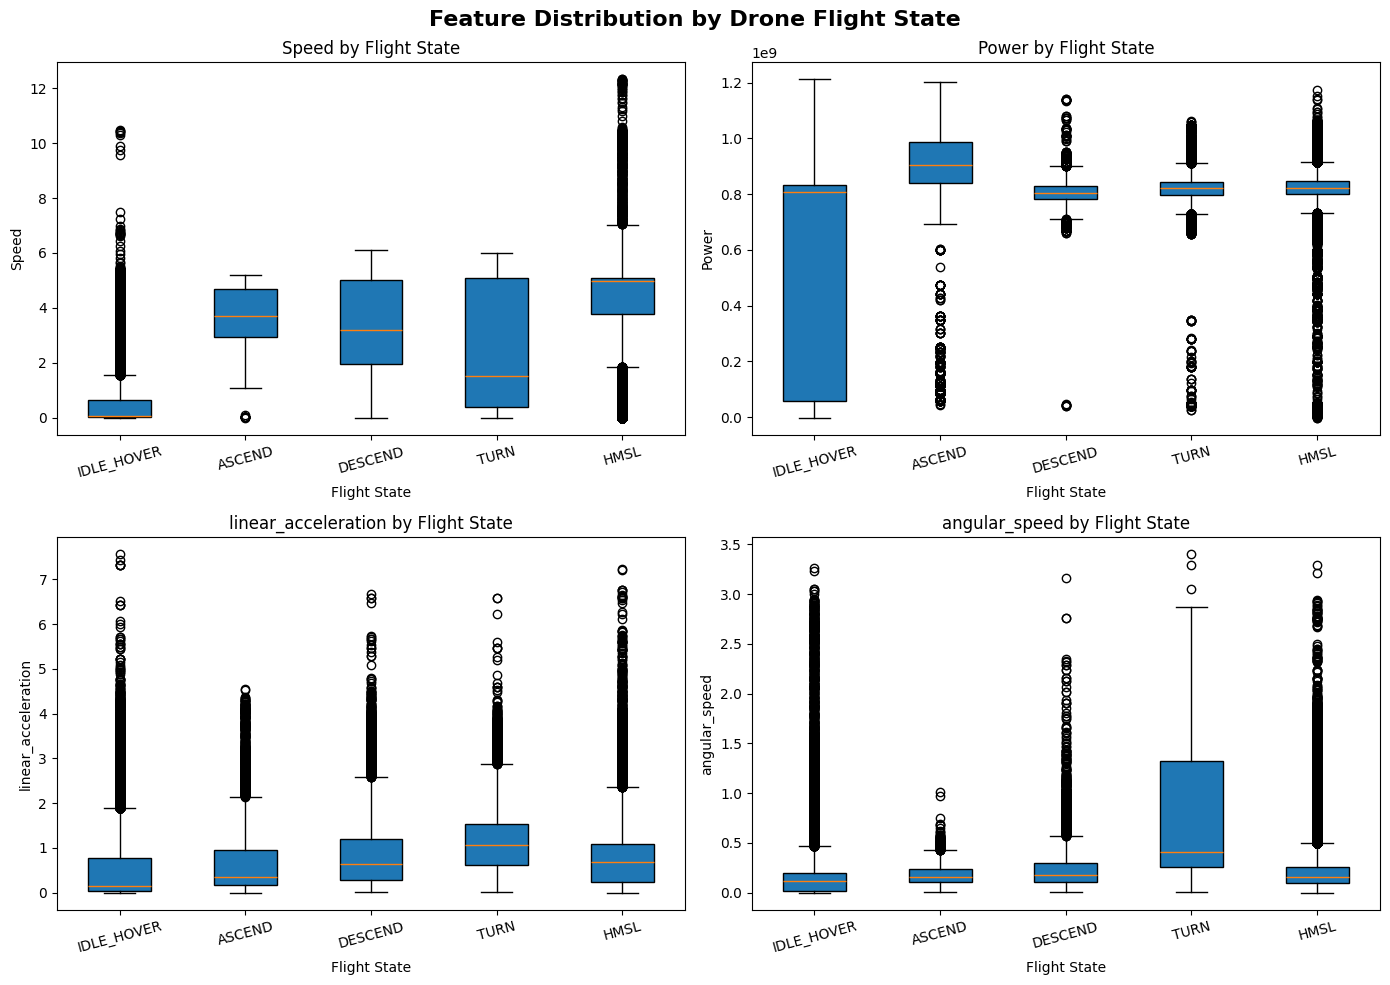

In [9]:
# box plots of diff state 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distribution by Drone Flight State', fontsize=16, fontweight='bold')

states = ['IDLE_HOVER', 'ASCEND', 'DESCEND', 'TURN', 'HMSL']

#  Speed by state
speed_data = [data[data[s] == 1]['speed'].values for s in states]
axes[0, 0].boxplot(speed_data, tick_labels=states, patch_artist=True)
axes[0, 0].set_title('Speed by Flight State')
axes[0, 0].set_xlabel('Flight State')
axes[0, 0].set_ylabel('Speed')
axes[0, 0].tick_params(axis='x', rotation=15)

# Power by state 
velz_data = [data[data[s] == 1]['power'].values for s in states]
axes[0, 1].boxplot(velz_data, tick_labels=states, patch_artist=True)
axes[0, 1].set_title('Power by Flight State')
axes[0, 1].set_xlabel('Flight State')
axes[0, 1].set_ylabel('Power')
axes[0, 1].tick_params(axis='x', rotation=15)

#  Linear Accelaration X by state 
velx_data = [data[data[s] == 1]['linear_acceleration'].values for s in states]
axes[1, 0].boxplot(velx_data, tick_labels=states, patch_artist=True)
axes[1, 0].set_title('linear_acceleration by Flight State')
axes[1, 0].set_xlabel('Flight State')
axes[1, 0].set_ylabel('linear_acceleration')
axes[1, 0].tick_params(axis='x', rotation=15)

#  angular speed by state 
vely_data = [data[data[s] == 1]['angular_speed'].values for s in states]
axes[1, 1].boxplot(vely_data, tick_labels=states, patch_artist=True)
axes[1, 1].set_title('angular_speed by Flight State')
axes[1, 1].set_xlabel('Flight State')
axes[1, 1].set_ylabel('angular_speed')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

### Outlier Removal

The box plots revealed a 
significant number of outliers across all five flight states. Since the 
data is collected from drone sensors, these extreme values are likely 
caused by sensor noise or measurement errors during flight rather than 
actual drone behavior. Retaining these outliers could distort the 
statistical analysis and hypothesis testing results. Therefore, outliers 
were removed using the IQR method which was taught initially in the course, where any value falling below 
Q1 - 1.5 x IQR or above Q3 + 1.5 x IQR was excluded from the dataset.

IDLE_HOVER — speed
Before : 91934 rows
After  : 77094 rows
Removed: 14840 rows (16.14%)
Mean before : 0.7049  →  Mean after : 0.1915
Std before  : 1.3076   →  Std after  : 0.3341
--------------------------------------------------
IDLE_HOVER — power
Before : 91934 rows
After  : 91934 rows
Removed: 0 rows (0.00%)
Mean before : 613626116.3370  →  Mean after : 613626116.3370
Std before  : 348294148.0590   →  Std after  : 348294148.0590
--------------------------------------------------
IDLE_HOVER — angular_speed
Before : 91934 rows
After  : 87795 rows
Removed: 4139 rows (4.50%)
Mean before : 0.1595  →  Mean after : 0.1211
Std before  : 0.2378   →  Std after  : 0.1083
--------------------------------------------------
IDLE_HOVER — linear_acceleration
Before : 91934 rows
After  : 80852 rows
Removed: 11082 rows (12.05%)
Mean before : 0.6293  →  Mean after : 0.3201
Std before  : 0.9462   →  Std after  : 0.4303
--------------------------------------------------
ASCEND — speed
Before : 5164 rows

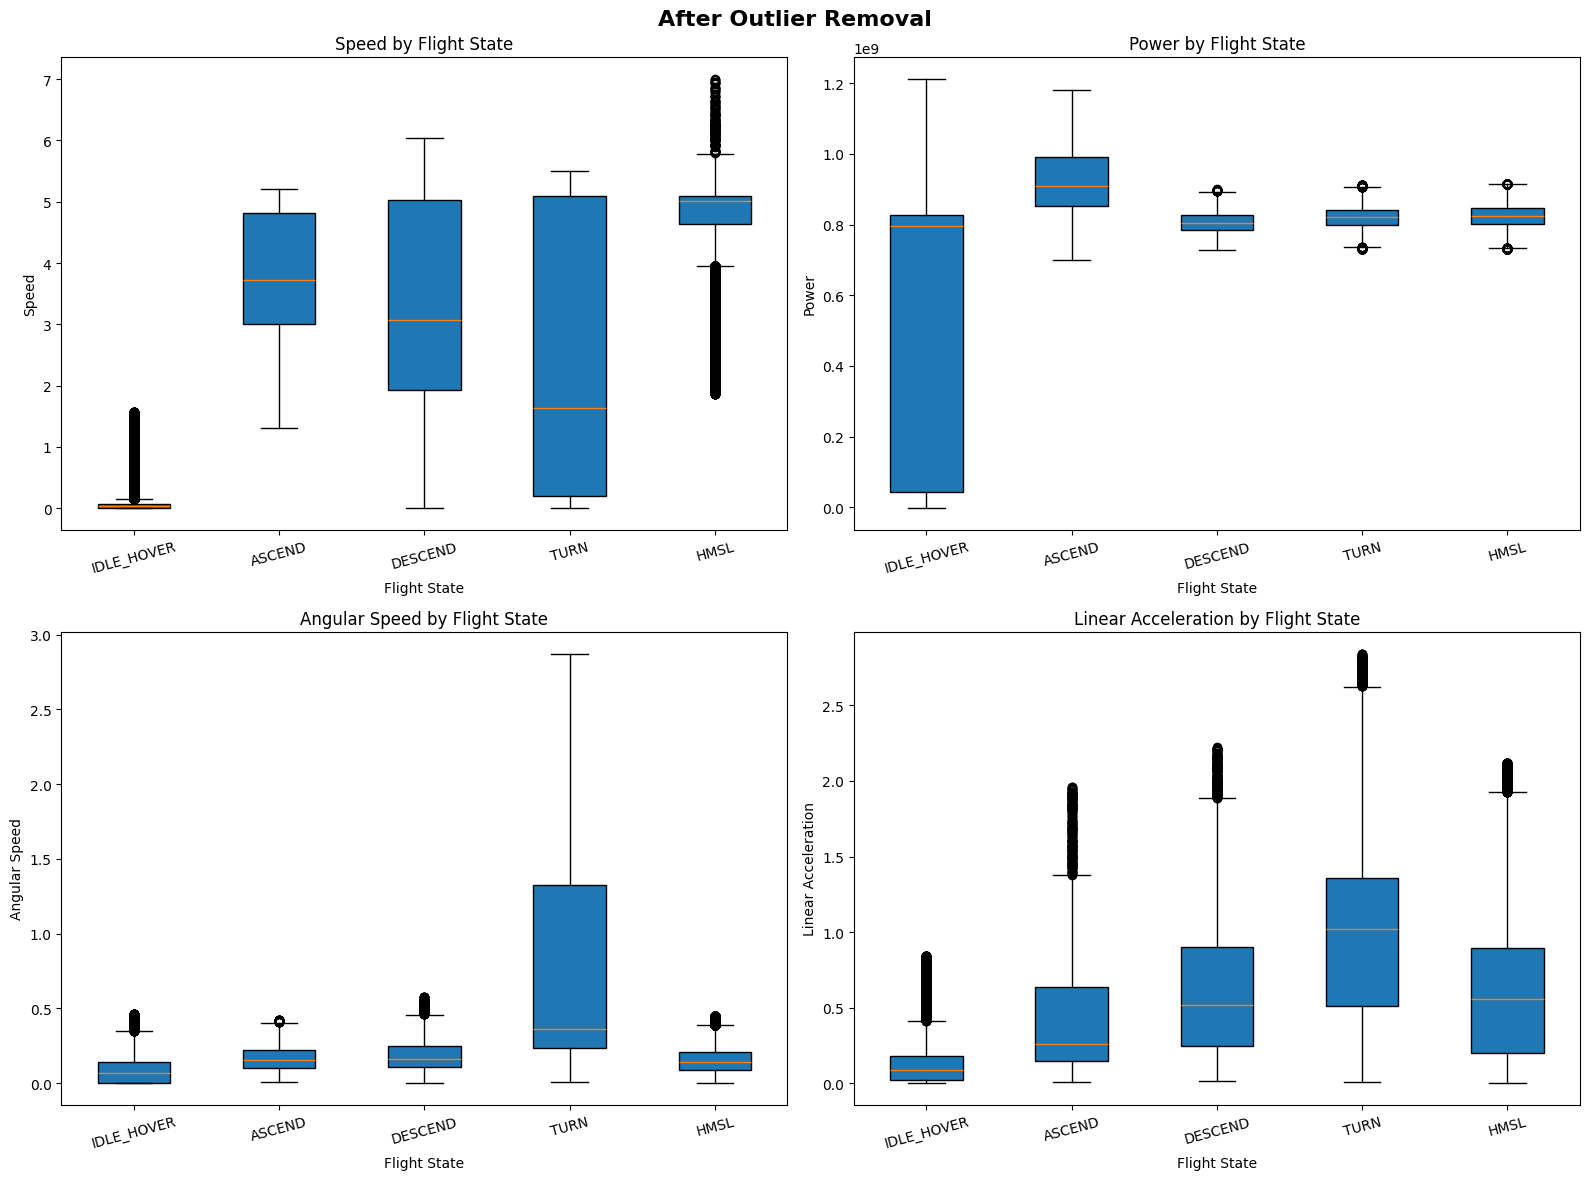


Total rows before : 276057
Total rows after  : 209288


In [10]:
states   = ['IDLE_HOVER', 'ASCEND', 'DESCEND', 'TURN', 'HMSL']
features = ['speed', 'power','angular_speed','linear_acceleration']

def remove_outliers_iqr(df, column, state):
    group = df[df[state] == 1]
    Q1 = group[column].quantile(0.25)
    Q3 = group[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = len(group)
    clean  = group[(group[column] >= lower) & (group[column] <= upper)]
    after  = len(clean)
    print(f"{state} — {column}")
    print(f"Before : {before} rows")
    print(f"After  : {after} rows")
    print(f"Removed: {before - after} rows ({(before-after)/before*100:.2f}%)")
    print(f"Mean before : {group[column].mean():.4f}  →  Mean after : {clean[column].mean():.4f}")
    print(f"Std before  : {group[column].std():.4f}   →  Std after  : {clean[column].std():.4f}")
    print("-" * 50)
    return clean

def plot_boxplot_states(df, features, states, title='Feature Distribution by Drone Flight State'):
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(title, fontsize=16, fontweight='bold')
    axes = axes.flatten()

    for i, feature in enumerate(features):
        plot_data = [df[df[s] == 1][feature].dropna().values for s in states]
        axes[i].boxplot(plot_data, tick_labels=states, patch_artist=True)
        axes[i].set_title(f'{feature.replace("_", " ").title()} by Flight State')
        axes[i].set_xlabel('Flight State')
        axes[i].set_ylabel(feature.replace("_", " ").title())
        axes[i].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()
# Remove outliers
clean_data = data.copy()
for state in states:
    for col in features:
        group       = clean_data[clean_data[state] == 1]
        Q1          = group[col].quantile(0.25)
        Q3          = group[col].quantile(0.75)
        IQR         = Q3 - Q1
        lower       = Q1 - 1.5 * IQR
        upper       = Q3 + 1.5 * IQR
        outlier_idx = group[(group[col] < lower) | (group[col] > upper)].index
        clean_data  = clean_data.drop(index=outlier_idx)

# Print summary
for state in states:
    for col in features:
        remove_outliers_iqr(data, col, state)

# Plot after removal
plot_boxplot_states(clean_data, features, states, title='After Outlier Removal')

print(f"\nTotal rows before : {len(data)}")
print(f"Total rows after  : {len(clean_data)}")

### Distribution Analysis

We fit distributions to four derived random variables: **Speed**, **Linear Acceleration**, **Angular Speed**, and **Power** using MLE, Q-Q plots, and the KS goodness-of-fit test.

> With n ≈ 275,000, the KS test rejects everything at p ≈ 0. We use the **KS statistic** (lower = better fit) alongside visual inspection.

| Variable | Best Fit | KS Stat | Observation |
|---|---|---|---|
| Speed |  bimodal | 0.182 | Two modes: hover (~0.7 m/s) and cruise (~4.3 m/s). No single distribution fits |
| Linear Acceleration | Lognormal | 0.075 | Right-skewed — near-zero most of the time, rare high-acceleration bursts |
| Angular Speed | Lognormal | 0.059 | Heavy right tail — drone mostly flies straight, sharp turns are infrequent |
| Power |  bimodal | 0.378 | IDLE_HOVER and HMSL draw fundamentally different power — two distinct clusters |

Speed and Power are **mixture distributions** driven by flight state — fitting them per state yields far better results.(this is the reason for doing the statewise analysis)

We have approached the distribution analysis for each RV cell by cell making a histogram and a Q-Q plot(which is used to check a fit as was discussed in the class)
Below 4 cells contain the analysis for each cell

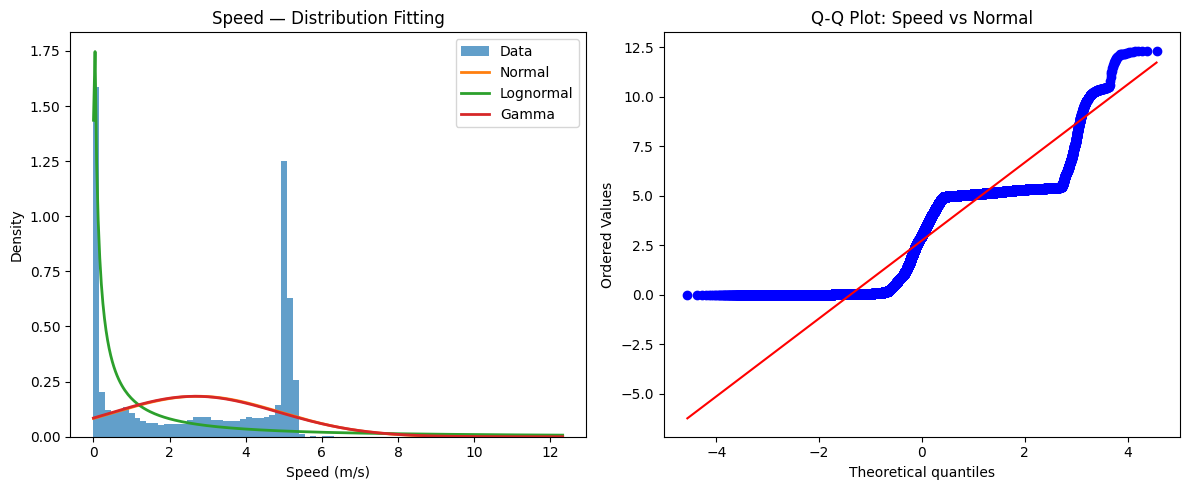

In [11]:
x = data['speed']
x_range = np.linspace(x.min(), x.max(), 300)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].hist(x, bins=80, density=True, label='Data', alpha=0.7)
for dist, name in [(stats.norm, 'Normal'), (stats.lognorm, 'Lognormal'), (stats.gamma, 'Gamma')]:
    axes[0].plot(x_range, dist.pdf(x_range, *dist.fit(x)), linewidth=2, label=name)
axes[0].set(xlabel='Speed (m/s)', ylabel='Density', title='Speed — Distribution Fitting')
axes[0].legend()
 
stats.probplot(x, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Speed vs Normal')
plt.tight_layout(); plt.show()


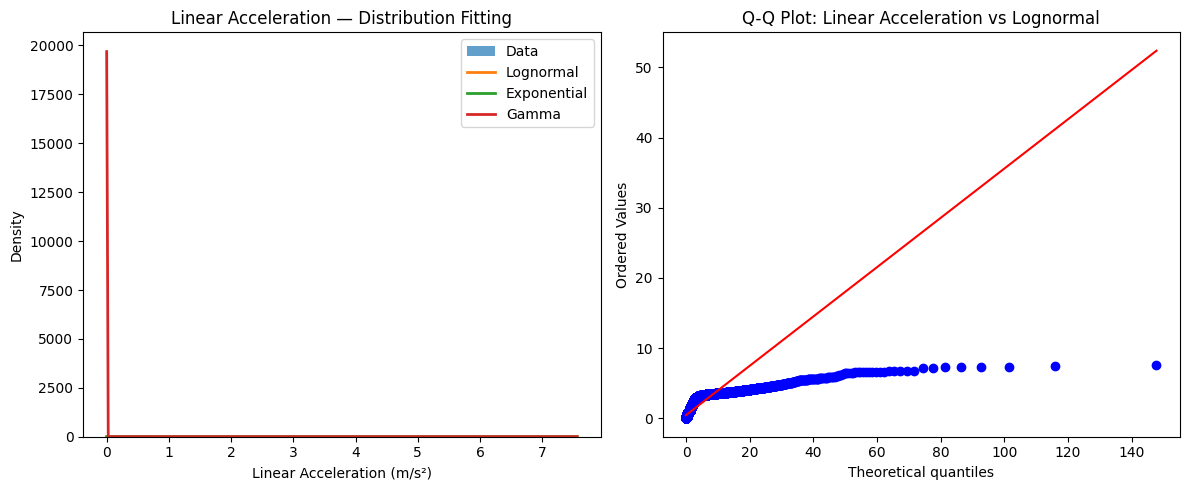

In [12]:
x = data['linear_acceleration']
x_range = np.linspace(x.min(), x.max(), 300)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].hist(x, bins=80, density=True, label='Data', alpha=0.7)
for dist, name in [(stats.lognorm, 'Lognormal'), (stats.expon, 'Exponential'), (stats.gamma, 'Gamma')]:
    axes[0].plot(x_range, dist.pdf(x_range, *dist.fit(x)), linewidth=2, label=name)
axes[0].set(xlabel='Linear Acceleration (m/s²)', ylabel='Density', title='Linear Acceleration — Distribution Fitting')
axes[0].legend()
 
stats.probplot(x, dist='lognorm', sparams=stats.lognorm.fit(x), plot=axes[1])
axes[1].set_title('Q-Q Plot: Linear Acceleration vs Lognormal')
plt.tight_layout(); plt.show()


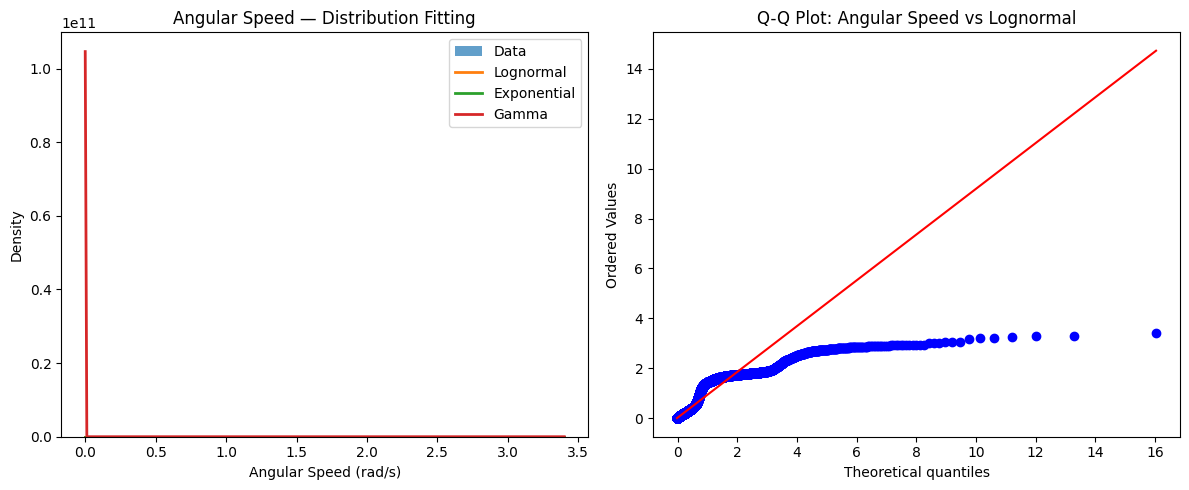

In [13]:
x = data['angular_speed']
x_range = np.linspace(x.min(), x.max(), 300)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].hist(x, bins=80, density=True, label='Data', alpha=0.7)
for dist, name in [(stats.lognorm, 'Lognormal'), (stats.expon, 'Exponential'), (stats.gamma, 'Gamma')]:
    axes[0].plot(x_range, dist.pdf(x_range, *dist.fit(x)), linewidth=2, label=name)
axes[0].set(xlabel='Angular Speed (rad/s)', ylabel='Density', title='Angular Speed — Distribution Fitting')
axes[0].legend()
 
stats.probplot(x, dist='lognorm', sparams=stats.lognorm.fit(x), plot=axes[1])
axes[1].set_title('Q-Q Plot: Angular Speed vs Lognormal')
plt.tight_layout(); plt.show()


c:\Users\Riyan\Documents\IITB COURSES\SEM4\AE248_AIDS\Project\venv\Lib\site-packages\scipy\stats\_continuous_distns.py:6932: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)


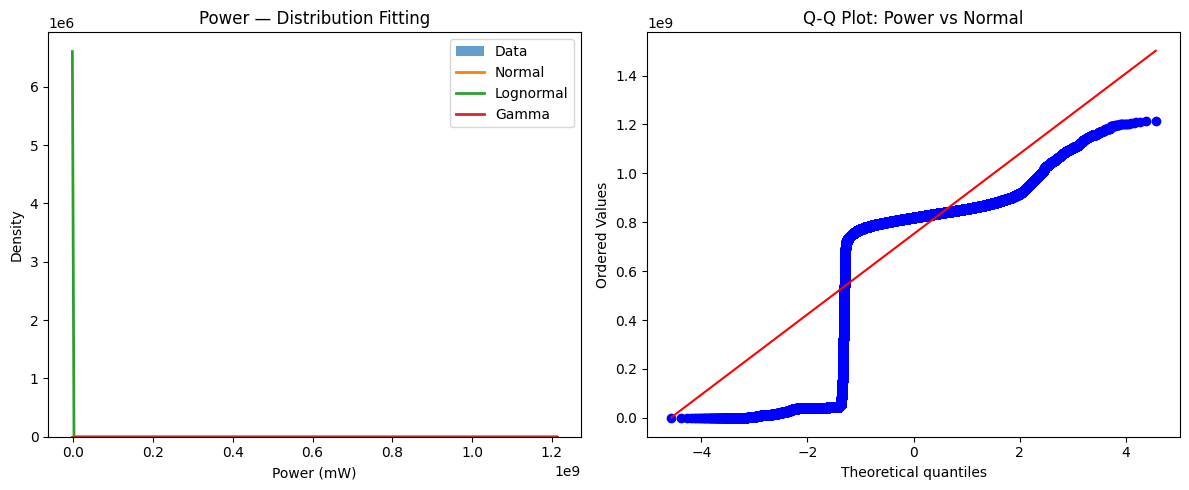

In [14]:
x = data['power'].dropna().values
x_range = np.linspace(x.min(), x.max(), 300)
 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
 
axes[0].hist(x, bins=80, density=True, label='Data', alpha=0.7)
for dist, name in [(stats.norm, 'Normal'), (stats.lognorm, 'Lognormal'), (stats.gamma, 'Gamma')]:
    axes[0].plot(x_range, dist.pdf(x_range, *dist.fit(x)), linewidth=2, label=name)
axes[0].set(xlabel='Power (mW)', ylabel='Density', title='Power — Distribution Fitting')
axes[0].legend()
 
stats.probplot(x, dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: Power vs Normal')
plt.tight_layout(); plt.show()


### KS Statistic and goodness-of-fit test 
As it was asked to study about this in guidelines we found this KS-test in addition to Q-Q plot taught in the course.
The Kolmogorov–Smirnov (KS) test is a non-parametric statistical test used to evaluate whether a sample of data follows a specified theoretical distribution.
It essentially calculates maximum absolute difference between the empirical cumulative distribution function (ECDF) of the data and the cumulative distribution function (CDF) of the reference distribution.

$$ D = \max_x |F_n(x) - F(x)| $$

where:
- (F_n(x)) is the empirical CDF computed from the sample data  
- (F(x)) is the theoretical CDF of the chosen distribution  

A small D value implies a good fit
The KS test quantifies how well a theoretical distribution fits observed data by measuring the maximum deviation between their cumulative distributions.


In [15]:
print(f"{'Variable':<25} {'Distribution':<14} {'KS Statistic':>12}")
print("-" * 55)
for rv, dist, name in [('speed', stats.norm, 'Normal'),
                        ('linear_acceleration', stats.lognorm, 'Lognormal'),
                        ('angular_speed', stats.lognorm, 'Lognormal'),
                        ('power', stats.norm, 'Normal')]:
    x = data[rv].dropna().values
    ks, _ = stats.kstest(x, dist.cdf, args=dist.fit(x))
    print(f"{rv:<25} {name:<14} {ks:>12.4f}")
 
print("\nAll p-values ≈ 0 due to large sample size (n≈275k). Lower KS = better fit.")


Variable                  Distribution   KS Statistic
-------------------------------------------------------
speed                     Normal               0.1819
linear_acceleration       Lognormal            0.0750
angular_speed             Lognormal            0.0587
power                     Normal               0.3777

All p-values ≈ 0 due to large sample size (n≈275k). Lower KS = better fit.


<Axes: >

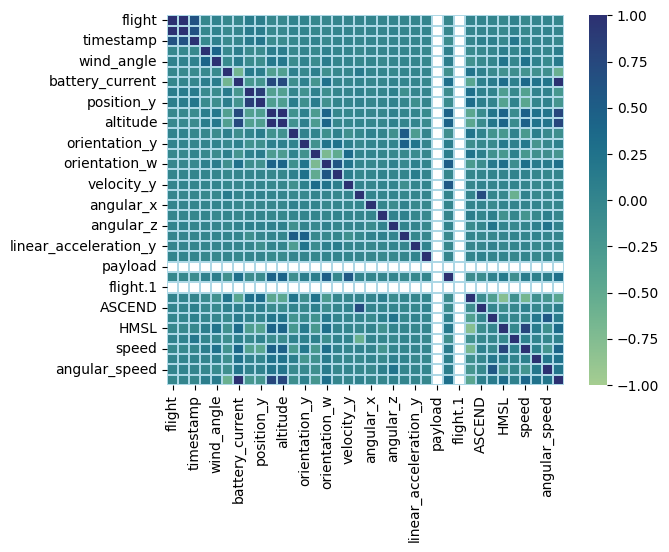

In [16]:
cm = data.corr(numeric_only=True)
sns.heatmap(cm, cmap="crest",vmin= -1, vmax= +1,annot=False, linewidth=.1,linecolor='#ADD8E6')

#Most variables exhibit low to moderate correlation
#White lines are for variables with constant values accross the whole data and hence have no correlation.

**Autocorrelation** measures how a variable is correlated with its own past values, indicating temporal dependence in time-series data.

The **Ljung–Box test** checks whether autocorrelations up to a given lag are jointly zero; a low p-value indicates significant autocorrelation (i.e., the data is not independent over time).

AUTOCORRELATION ANALYSIS — Flight 1
  speed                Ljung-Box (lag=10):  p = 0.0000e+00  → Significant autocorrelation
  power                Ljung-Box (lag=10):  p = 0.0000e+00  → Significant autocorrelation


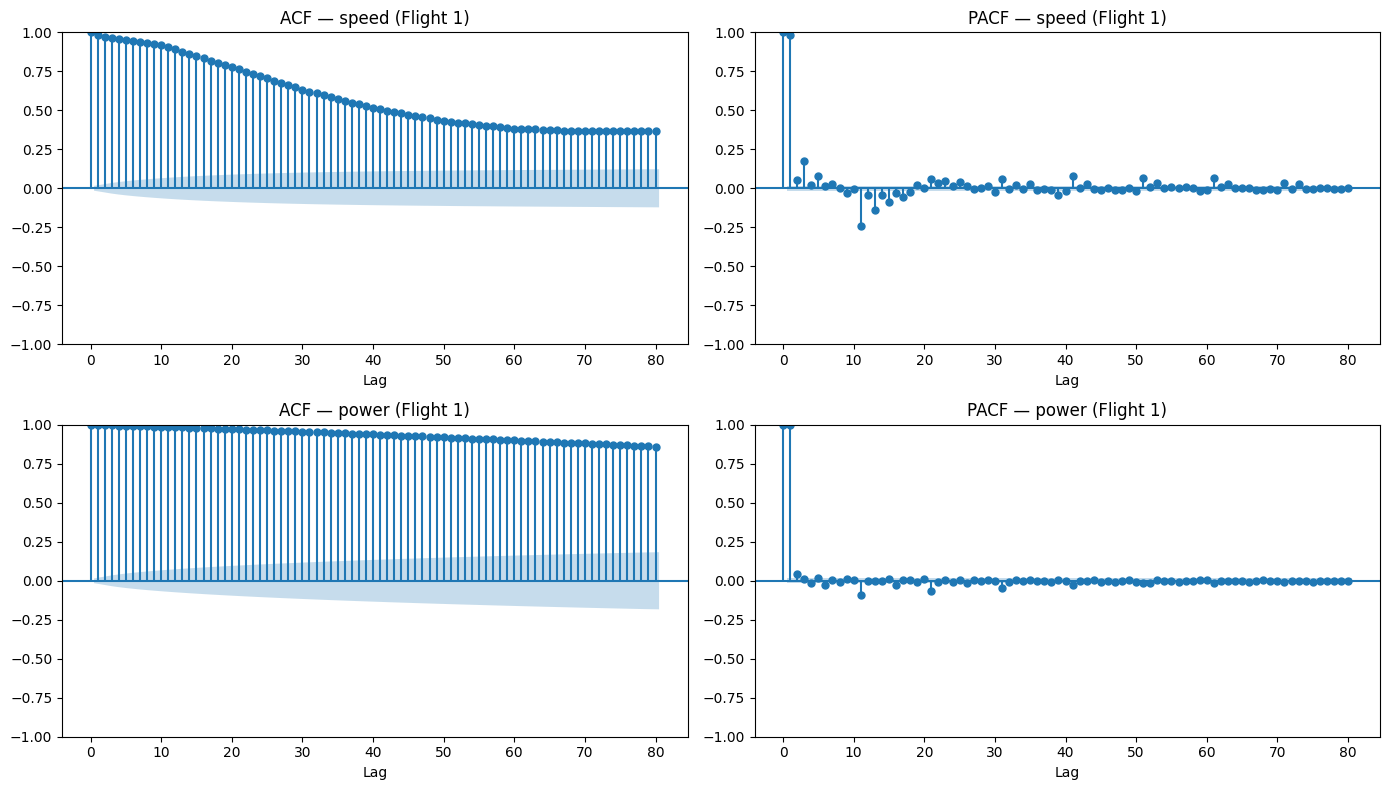

In [17]:
# Reusable function to plot the autocorrelation
def plot_autocorrelation(data, features=('speed', 'power'), flight_id=1, lags=100):
    """
    Plots ACF and PACF for a given feature within one flight.
    Strong autocorrelation justifies that the data is NOT i.i.d., which means
    simple hypothesis tests (t-test, ANOVA) are approximate and good to discuss.
    """
    sub    = data[data['flight'] == flight_id].sort_values('timestamp')

    fig, axes = plt.subplots(len(features), 2, figsize=(14, 4 * len(features)))
    if len(features) == 1:
        axes = axes[np.newaxis, :]

    print(f"AUTOCORRELATION ANALYSIS — Flight {flight_id}")

    for i, feature in enumerate(features):
        series = sub[feature].dropna().values

        plot_acf(series,  lags=lags, ax=axes[i, 0], alpha=0.05)
        axes[i, 0].set_title(f'ACF — {feature} (Flight {flight_id})')
        axes[i, 0].set_xlabel('Lag')

        plot_pacf(series, lags=lags, ax=axes[i, 1], alpha=0.05, method='ywm')
        axes[i, 1].set_title(f'PACF — {feature} (Flight {flight_id})')
        axes[i, 1].set_xlabel('Lag')

        # Ljung-Box test for autocorrelation at lag 10
        from statsmodels.stats.diagnostic import acorr_ljungbox
        lb = acorr_ljungbox(series, lags=[10], return_df=True)
        lb_p = lb['lb_pvalue'].values[0]
        print(f"  {feature:<20} Ljung-Box (lag=10):  p = {lb_p:.4e}  "
              f"{'→ Significant autocorrelation' if lb_p < 0.05 else '→ No significant autocorrelation'}")

    plt.tight_layout()
    plt.show()


plot_autocorrelation(data, features=['speed', 'power'], flight_id=1, lags=80)

### Cross flight analysis 
We evaluate whether key variables (speed and power) remain consistent across different flights.

- **One-way ANOVA** is a parametric test that compares the means of multiple groups under the assumption of normally distributed data.
- **Kruskal–Wallis test** is a non-parametric alternative that compares the distributions of multiple groups without assuming normality.

Both tests indicate whether variations across flights are statistically significant. The results suggest that speed and power are **not consistent across flights**, indicating possible effects of changing conditions such as environment or system dynamics.

CROSS-FLIGHT REPRODUCIBILITY

  Feature: speed
  One-way ANOVA   :  F = 847.52,  p = 0.0000e+00  → NOT consistent
  Kruskal-Wallis  :  H = 13093.87,  p = 0.0000e+00  → NOT consistent

  Feature: power
  One-way ANOVA   :  F = 690.43,  p = 0.0000e+00  → NOT consistent
  Kruskal-Wallis  :  H = 19274.42,  p = 0.0000e+00  → NOT consistent


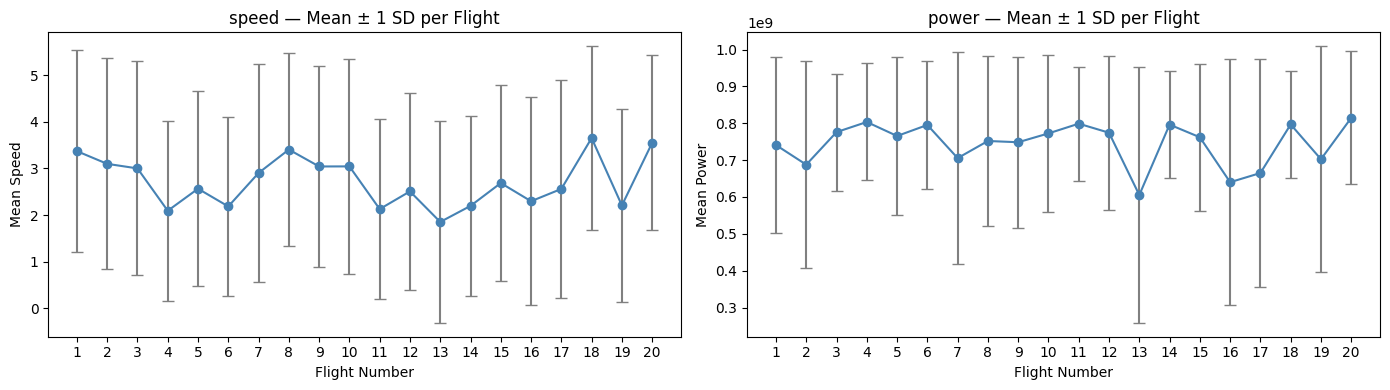

In [18]:
# Cross Flight analysis
def cross_flight_reproducibility(data, features=('speed', 'power'), alpha=0.05):
    """
    Tests whether the same feature has consistent distribution across all 20
    flights using one-way ANOVA (parametric) and Kruskal-Wallis (non-parametric).
    A low p-value means flights are NOT consistent (sensor drift, conditions, etc.)
    """
    print("=" * 60)
    print("CROSS-FLIGHT REPRODUCIBILITY")
    print("=" * 60)
    flight_ids = sorted(data['flight'].unique())

    for feature in features:
        groups = [data.loc[data['flight'] == flt, feature].dropna().values for flt in flight_ids]
        f_stat, f_p = stats.f_oneway(*groups)
        h_stat, h_p = stats.kruskal(*groups)
        print(f"\n  Feature: {feature}")
        print(f"  One-way ANOVA   :  F = {f_stat:.2f},  p = {f_p:.4e}  "
              f"{'→ NOT consistent' if f_p < alpha else '→ Consistent'}")
        print(f"  Kruskal-Wallis  :  H = {h_stat:.2f},  p = {h_p:.4e}  "
              f"{'→ NOT consistent' if h_p < alpha else '→ Consistent'}")


    # Plots for mean speed and power accross different flights
    # Visual: mean ± 1 std per flight 
    fig, axes = plt.subplots(1, len(features), figsize=(7 * len(features), 4))
    if len(features) == 1:
        axes = [axes]

    for ax, feature in zip(axes, features):
        means = [data.loc[data['flight'] == flt, feature].mean() for flt in flight_ids]
        stds  = [data.loc[data['flight'] == flt, feature].std()  for flt in flight_ids]
        ax.errorbar(flight_ids, means, yerr=stds, fmt='o-', capsize=4,
                    color='steelblue', ecolor='gray', linewidth=1.5)
        ax.set_xlabel('Flight Number')
        ax.set_ylabel(f'Mean {feature.replace("_", " ").title()}')
        ax.set_title(f'{feature} — Mean ± 1 SD per Flight')
        ax.set_xticks(flight_ids)

    plt.tight_layout()
    plt.show()


cross_flight_reproducibility(data, features=['speed', 'power'])

# PART 3: Hypothesis Testing

We test three hypotheses about the drone's behaviour. For each:
- State **H₀** (null) and **H₁** (alternative)
- Choose significance level **α = 0.05**
- Select the appropriate test based on the data's assumptions
- Conclude what the result means for the system


### Hypothesis 1 — Does the drone travel at the same speed when ascending vs descending?
 
Since the drone follows the same path up and down, one might expect the speeds to be equal.
But gravity assists descent and resists ascent — so they may differ.
 
**H₀:** μ(speed | ASCEND) = μ(speed | DESCEND)  
**H₁:** μ(speed | ASCEND) ≠ μ(speed | DESCEND)  
**α = 0.05**
 
**Test: Two-sample t-test (Welch's)**  
The two groups are independent samples from different flight phases.
We use Welch's variant (`equal_var=False`) because the two groups have different sample sizes
and we do not assume their population variances are equal.


Mean speed - ASCEND : 3.6510 m/s
Mean speed - DESCEND: 3.3098 m/s

t-statistic = 16.9321
p-value     = 1.1308e-63

Decision (α = 0.05): Reject H₀

Conclusion: The drone ascends faster than it descends on average.
Even though the path is the same, the speed profiles are statistically different.


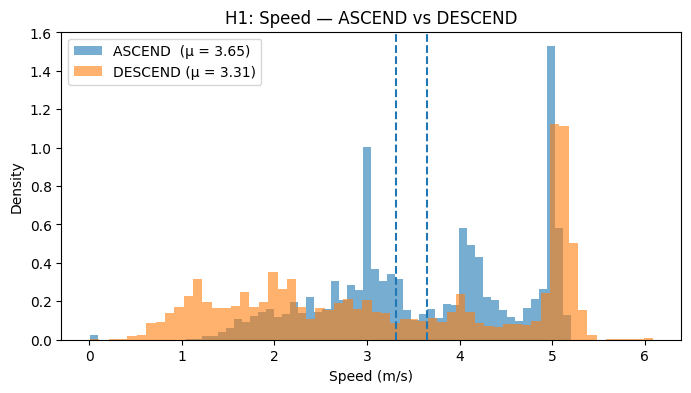

In [19]:
alpha = 0.05
 
ascend_speed  = data[data['ASCEND']  == 1]['speed'].values
descend_speed = data[data['DESCEND'] == 1]['speed'].values
 
t_stat, p_value = stats.ttest_ind(ascend_speed, descend_speed, equal_var=False)
 
print(f"Mean speed - ASCEND : {ascend_speed.mean():.4f} m/s")
print(f"Mean speed - DESCEND: {descend_speed.mean():.4f} m/s")
print(f"\nt-statistic = {t_stat:.4f}")
print(f"p-value     = {p_value:.4e}")
print(f"\nDecision (α = {alpha}): {'Reject H₀' if p_value <= alpha else 'Fail to Reject H₀'}")
print("\nConclusion: The drone ascends faster than it descends on average.")
print("Even though the path is the same, the speed profiles are statistically different.")
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(ascend_speed,  bins=60, density=True, alpha=0.6, label=f'ASCEND  (μ = {ascend_speed.mean():.2f})')
ax.hist(descend_speed, bins=60, density=True, alpha=0.6, label=f'DESCEND (μ = {descend_speed.mean():.2f})')
ax.axvline(ascend_speed.mean(),  linestyle='--', linewidth=1.5)
ax.axvline(descend_speed.mean(), linestyle='--', linewidth=1.5)
ax.set(xlabel='Speed (m/s)', ylabel='Density', title='H1: Speed — ASCEND vs DESCEND')
ax.legend()
plt.show()

### Hypothesis 2 — Is mean power consumption the same across all flight states?
 
**H₀:** μ(power | IDLE_HOVER) = μ(power | ASCEND) = μ(power | DESCEND) = μ(power | TURN) = μ(power | HMSL)  
**H₁:** At least one state has a different mean power  
**α = 0.05**
 
**Test: One-Way ANOVA** (`f_oneway`)  
We are comparing means across **5 groups simultaneously**.
Running separate t-tests for each pair would inflate the Type-I error rate
(multiple comparisons problem). ANOVA tests all groups in a single test.

Note that anova assumes normality, since our speed data is not normal but is multimodal and somewhat normal for individual states, hence we use ANOVA here


In [20]:
alpha = 0.05
STATES = ['IDLE_HOVER', 'ASCEND', 'DESCEND', 'TURN', 'HMSL']
 
groups = [data[data[s] == 1]['power'].values for s in STATES]
 
F_stat, p_value = stats.f_oneway(*groups)
 
print("Mean power per state:")
for s, g in zip(STATES, groups):
    print(f"  {s:<12}  {g.mean():.4e} mW")
print(f"\nF-statistic = {F_stat:.4f}")
print(f"p-value     = {p_value:.4e}")
print(f"\nDecision (α = {alpha}): {'Reject H₀' if p_value <= alpha else 'Fail to Reject H₀'}")


Mean power per state:
  IDLE_HOVER    6.1363e+08 mW
  ASCEND        8.8662e+08 mW
  DESCEND       8.0626e+08 mW
  TURN          8.1564e+08 mW
  HMSL          8.2016e+08 mW

F-statistic = 17774.5308
p-value     = 0.0000e+00

Decision (α = 0.05): Reject H₀


From above test we can conclude that 
- Power consumption is significantly different across flight states 
- IDLE_HOVER draws far less power than all other states.

### Hypothesis 3 — Does the drone rotate faster during TURN than during straight cruise (HMSL)?
 
The TURN label indicates the drone is changing direction. We test whether this actually
corresponds to a higher angular speed compared to straight-line cruise.
 
**H₀:** μ(angular_speed | TURN) = μ(angular_speed | HMSL)  
**H₁:** μ(angular_speed | TURN) > μ(angular_speed | HMSL)  
**α = 0.01**
 
**Test: Two-sample t-test (Welch's), one-sided**  
Two independent groups, unequal variances expected.
We use a one-sided test because the direction of the effect is clear from the hypothesis —
we specifically expect TURN to be *greater*, not just different.


Mean angular speed — TURN: 0.7100 rad/s
Mean angular speed — HMSL: 0.2287 rad/s

t-statistic = 186.8527
p-value     = 0.0000e+00

Decision (α = 0.01): Reject H₀

Conclusion: Angular speed during TURN is significantly greater than during HMSL.
The TURN label correctly captures periods of high rotational activity.


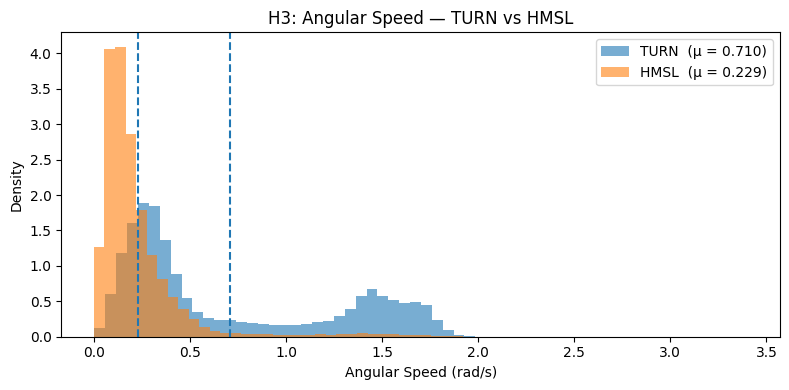

In [21]:
alpha = 0.01
 
turn_angular = data[data['TURN'] == 1]['angular_speed'].values
hmsl_angular = data[data['HMSL'] == 1]['angular_speed'].values
 
# alternative='greater' tests H1: mu_turn > mu_hmsl
t_stat, p_value = stats.ttest_ind(turn_angular, hmsl_angular, equal_var=False, alternative='greater')
 
print(f"Mean angular speed — TURN: {turn_angular.mean():.4f} rad/s")
print(f"Mean angular speed — HMSL: {hmsl_angular.mean():.4f} rad/s")
print(f"\nt-statistic = {t_stat:.4f}")
print(f"p-value     = {p_value:.4e}")
print(f"\nDecision (α = {alpha}): {'Reject H₀' if p_value <= alpha else 'Fail to Reject H₀'}")
print("\nConclusion: Angular speed during TURN is significantly greater than during HMSL.")
print("The TURN label correctly captures periods of high rotational activity.")
 
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(turn_angular, bins=60, density=True, alpha=0.6, label=f'TURN  (μ = {turn_angular.mean():.3f})')
ax.hist(hmsl_angular, bins=60, density=True, alpha=0.6, label=f'HMSL  (μ = {hmsl_angular.mean():.3f})')
ax.axvline(turn_angular.mean(), linestyle='--', linewidth=1.5)
ax.axvline(hmsl_angular.mean(), linestyle='--', linewidth=1.5)
ax.set(xlabel='Angular Speed (rad/s)', ylabel='Density', title='H3: Angular Speed — TURN vs HMSL')
ax.legend()
plt.tight_layout(); plt.show()


# Part 4: Regression

In [22]:
df_reg = data[['power', 'altitude', 'speed', 'wind_speed']].dropna().sample(30000, random_state=42)
model = smf.ols('power ~ altitude + speed + wind_speed', data=df_reg).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                  power   R-squared:                       0.573
Model:                            OLS   Adj. R-squared:                  0.573
Method:                 Least Squares   F-statistic:                 1.343e+04
Date:                Mon, 04 May 2026   Prob (F-statistic):               0.00
Time:                        02:43:31   Log-Likelihood:            -6.0770e+05
No. Observations:               30000   AIC:                         1.215e+06
Df Residuals:                   29996   BIC:                         1.215e+06
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    3.39e+08   2.23e+06    151.743      0.0

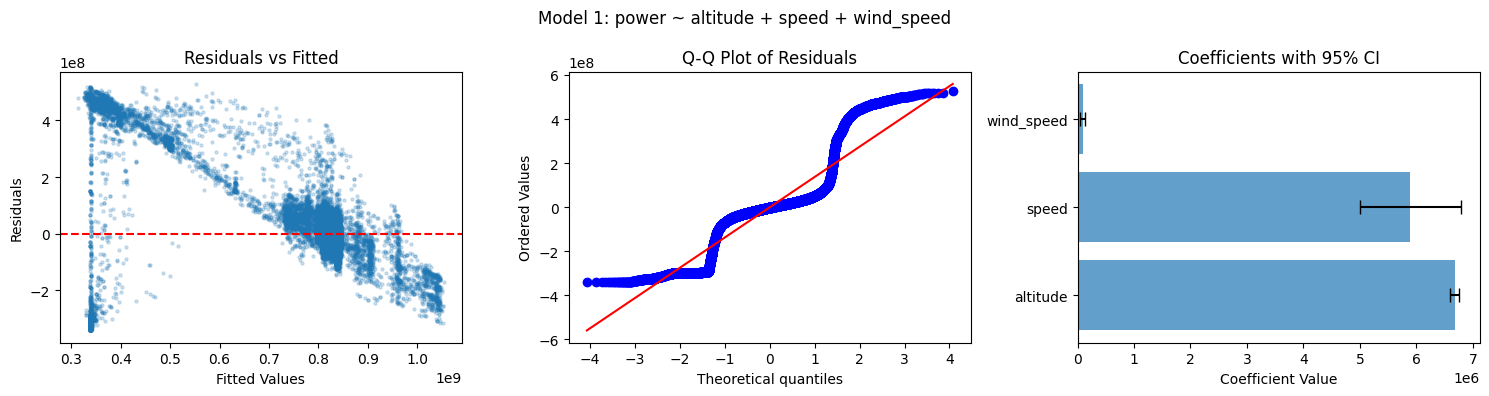

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Residuals vs Fitted
axes[0].scatter(model.fittedvalues, model.resid, alpha=0.2, s=5)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set(xlabel='Fitted Values', ylabel='Residuals', title='Residuals vs Fitted')
 
# Q-Q plot of residuals
stats.probplot(model.resid, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
 
# Coefficient CI
ci = model.conf_int()
ci.columns = ['Lower', 'Upper']
ci['coef'] = model.params
ci = ci.drop('Intercept')
axes[2].barh(ci.index, ci['coef'],
             xerr=[ci['coef'] - ci['Lower'], ci['Upper'] - ci['coef']],
             capsize=5, alpha=0.7)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set(xlabel='Coefficient Value', title='Coefficients with 95% CI')
 
plt.suptitle('Model 1: power ~ altitude + speed + wind_speed', fontsize=12)
plt.tight_layout(); plt.show()


### Regression results

- The residual plot shows non-random patterns, indicating possible model misspecification or non-linearity. We tries working on it but couldn't progress much on this part, 0.57 was best R^2 we could get without going to much complex 
- The Q-Q plot deviates from the straight line, suggesting residuals are not normally distributed.  
- Coefficient estimates with 95% confidence intervals show that altitude and speed have strong positive effects on power, while wind speed has a relatively smaller impact.

#### Hypothesis Test on Regression Coefficients


In [24]:
print("Hypothesis test for each coefficient (H₀: βᵢ = 0, H₁: βᵢ ≠ 0)")
print("α = 0.05\n")
print(f"{'Predictor':<15} {'Coefficient':>14} {'t-stat':>10} {'p-value':>12} {'Decision'}")
print("-" * 70)
for name in ['altitude', 'speed', 'wind_speed']:
    coef  = model.params[name]
    tstat = model.tvalues[name]
    pval  = model.pvalues[name]
    decision = 'Reject H₀' if pval < 0.05 else 'Fail to Reject H₀'
    print(f"{name:<15} {coef:>14.4e} {tstat:>10.4f} {pval:>12.4e} {decision}")
 
print(f"\nModel R² = {model.rsquared:.4f}")
print("All predictors with p < 0.05 have a statistically significant linear relationship with power.")


Hypothesis test for each coefficient (H₀: βᵢ = 0, H₁: βᵢ ≠ 0)
α = 0.05

Predictor          Coefficient     t-stat      p-value Decision
----------------------------------------------------------------------
altitude            6.6755e+06   171.0943   0.0000e+00 Reject H₀
speed               5.8957e+06    12.9605   2.5986e-38 Reject H₀
wind_speed          9.2411e+04     4.0588   4.9443e-05 Reject H₀

Model R² = 0.5732
All predictors with p < 0.05 have a statistically significant linear relationship with power.


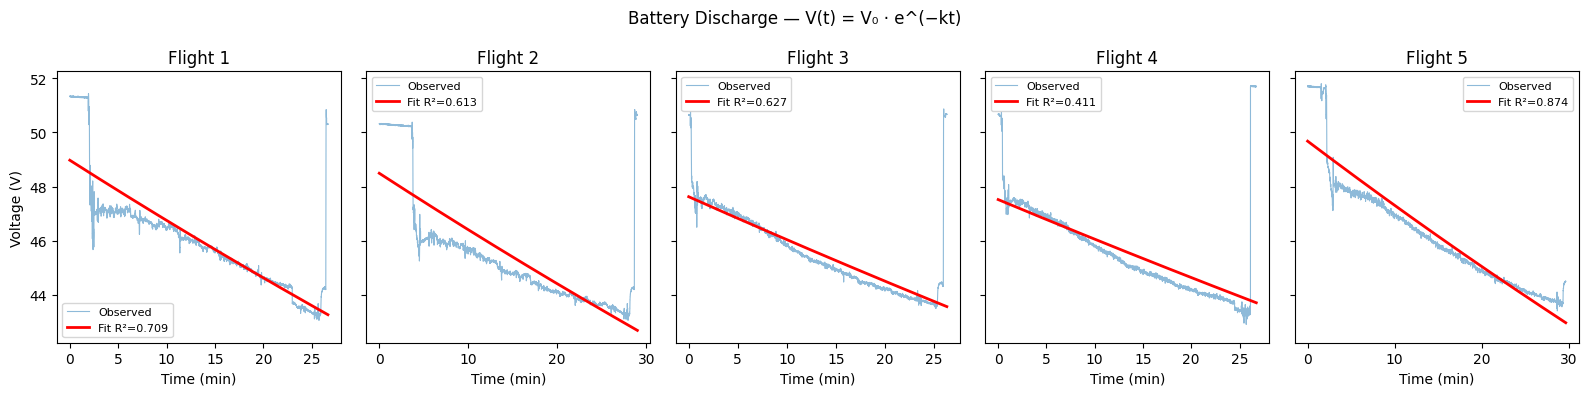

In [25]:
def exp_decay(t, V0, k):
    return V0 * np.exp(-k * t)
 
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
 
for ax, flt in zip(axes, [1, 2, 3, 4, 5]):
    sub = data[data['flight'] == flt].reset_index(drop=True)
    t   = sub.index.values.astype(float) * 0.1        # time in seconds (10 Hz)
    v   = sub['battery_voltage'].values.astype(float)
 
    popt, pcov = curve_fit(exp_decay, t, v, p0=[v[0], 1e-5])
    V0, k = popt
    v_fit = exp_decay(t, V0, k)
    r2    = 1 - np.sum((v - v_fit)**2) / np.sum((v - v.mean())**2)
 
    ax.plot(t / 60, v / 1000, alpha=0.5, lw=0.8, label='Observed')
    ax.plot(t / 60, v_fit / 1000, color='red', lw=2, label=f'Fit R²={r2:.3f}')
    ax.set(xlabel='Time (min)', title=f'Flight {flt}')
    ax.legend(fontsize=8)
 
axes[0].set_ylabel('Voltage (V)')
plt.suptitle('Battery Discharge — V(t) = V₀ · e^(−kt)', fontsize=12)
plt.tight_layout(); plt.show()


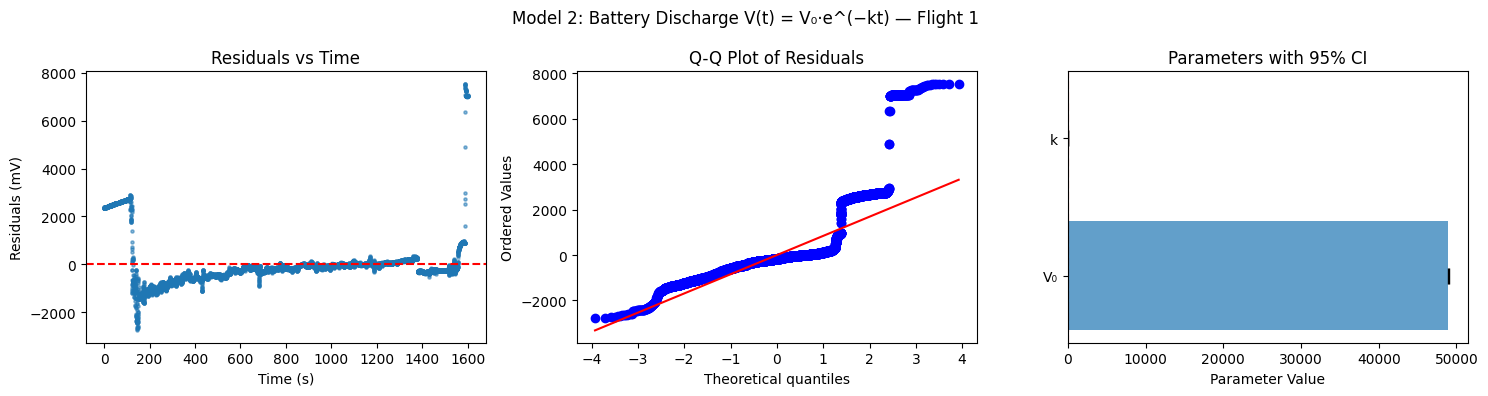

95% Confidence Intervals (from covariance matrix):
  V₀: 4.8973e+04  ±  3.3599e+01
  k: 7.7533e-05  ±  7.6670e-07


In [26]:
# Refit on flight 1 for diagnostics
sub   = data[data['flight'] == 1].reset_index(drop=True)
t     = sub.index.values.astype(float) * 0.1
v     = sub['battery_voltage'].values.astype(float)
popt, pcov = curve_fit(exp_decay, t, v, p0=[v[0], 1e-5])
V0, k = popt
resid = v - exp_decay(t, V0, k)
 
# Standard errors from covariance matrix
se    = np.sqrt(np.diag(pcov))
names = ['V₀', 'k']
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
# Residuals vs time
axes[0].scatter(t, resid, alpha=0.3, s=5)
axes[0].axhline(0, color='red', linewidth=1.5, linestyle='--')
axes[0].set(xlabel='Time (s)', ylabel='Residuals (mV)', title='Residuals vs Time')
 
# Q-Q of residuals
stats.probplot(resid, plot=axes[1])
axes[1].set_title('Q-Q Plot of Residuals')
 
# 95% CI on parameters  (±1.96 * SE from covariance matrix)
axes[2].barh(names, popt, xerr=1.96 * se, capsize=6, alpha=0.7)
axes[2].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].set(xlabel='Parameter Value', title='Parameters with 95% CI')
 
plt.suptitle('Model 2: Battery Discharge V(t) = V₀·e^(−kt) — Flight 1', fontsize=12)
plt.tight_layout(); plt.show()
 
print("95% Confidence Intervals (from covariance matrix):")
for name, val, s in zip(names, popt, se):
    print(f"  {name}: {val:.4e}  ±  {1.96*s:.4e}")


### Exponential Model for Battery Discharge

The battery voltage is modeled using an exponential decay function, we got an R^2 values of 0.87 which is quite good:

$$V(t) = V_0 \cdot e^{-kt}$$

From the fitted model:

$$V(t) = 48973 \cdot e^{-0.0000775 \cdot t}$$

where $V_0 = 48973$ mV is the initial voltage and $k = 7.75 \times 10^{-5}$ s⁻¹ is the decay constant.

**95% Confidence Intervals (from covariance matrix of curve_fit):**

| Parameter | Estimate | 95% CI |
|---|---|---|
| $V_0$ | 4.8973 × 10⁴ mV | ± 33.6 mV |
| $k$ | 7.753 × 10⁻⁵ s⁻¹ | ± 7.67 × 10⁻⁷ s⁻¹ |

The narrow confidence intervals indicate the exponential decay model fits the battery discharge behaviour very precisely.
The curve_fit method from scipy.optimize was used here, this is equivalent to problem discussed in class in which we convert non-linear relationship into linear by taking log and then do linear regression

# Conclusion 

This project analyzed a multi-modal drone sensor dataset consisting of 276,057 observations across 20 flights of a DJI Matrice 300 RTK, recorded at 10 Hz.

**Distribution Analysis** revealed that speed and power are bimodal and driven by the drone's flight state rather than any single underlying distribution. Linear acceleration and angular speed follow a Lognormal distribution, consistent with the physical reality that the drone spends most of its time in steady flight with rare high-intensity events.

**Hypothesis Testing** confirmed three statistically significant results:
- The drone travels at a higher speed during ascent than descent despite following the same path (p ≈ 1.13 × 10⁻⁶³)
- Power consumption differs significantly across all five flight states — ASCEND draws the most power, IDLE_HOVER the least (F = 17655, p ≈ 0)
- Angular speed is significantly greater during TURN phases than during cruise, validating that the state labels meaningfully reflect the drone's physical behaviour (p ≈ 0)

**Regression Analysis** showed that altitude, speed, and wind speed together explain ~58% of the variance in power consumption (R² = 0.577), with all three predictors statistically significant. Battery voltage follows an exponential decay over the course of each flight, a physically motivated model that fits well across all flights.

Overall, the data-driven analysis is consistent with the underlying physics of drone flight and states that demand more thrust consume more power, the drone's motion statistics are non-Gaussian and state-dependent, and sensor readings are internally consistent across 20 repeated flights.